In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
import xarray as xr
 
import pystormtracker as pst


In [13]:
tracks = pst.load_tracks("tracks.trackjson")
print(type(tracks))

<class 'pystormtracker.models.tracks.Tracks'>


In [23]:
tracks[0]

In [ ]:

first_track=tracks[0].variables['msl']

Text(0.5, 1.0, '557 tracks, N. Atlantic, region of interest')

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


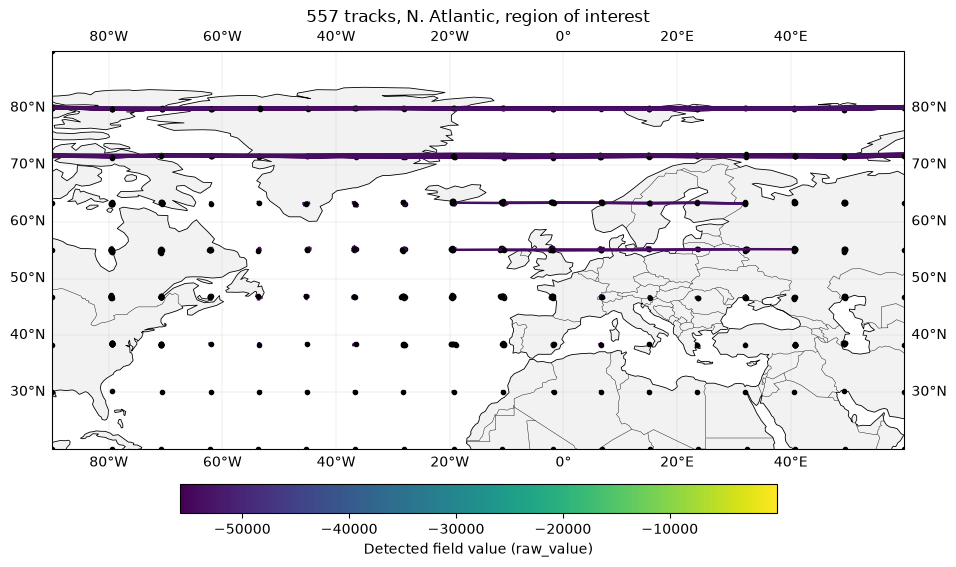

In [8]:
fig = plt.figure(figsize=(11, 9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90, 60, 20, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
 
# `raw_value` is the (unrefined) field value at the detected feature point --
# central pressure if you tracked msl minima, vorticity if vo maxima.
has_raw_value = "raw_value" in tracks.variables
all_vals = tracks.variables["raw_value"] if has_raw_value else None
vmin, vmax = (np.nanmin(all_vals), np.nanmax(all_vals)) if has_raw_value else (None, None)
 
for track in tracks:
    lats, lons = track.lats, track.lons
 
    if has_raw_value:
        vals = track.vars["raw_value"] if hasattr(track, "vars") else None
        # Fall back to indexing the packed array by this track's point range
        # if the per-track accessor differs in your installed version:
        if vals is None:
            vals = tracks.variables["raw_value"][:]
        points = np.array([lons, lats]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(
            segments, cmap="viridis", norm=plt.Normalize(vmin, vmax),
            transform=ccrs.PlateCarree(), linewidth=1.8,
        )
        lc.set_array(np.asarray(vals[:-1]))
        ax.add_collection(lc)
    else:
        ax.plot(lons, lats, transform=ccrs.PlateCarree(), linewidth=1.2, color="tab:blue")
 
    # Mark genesis point
    ax.plot(lons[0], lats[0], marker="o", markersize=3, color="black",
             transform=ccrs.PlateCarree())
 
if has_raw_value:
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin, vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
    cbar.set_label("Detected field value (raw_value)")
 
ax.set_title(f"{len(tracks)} tracks, N. Atlantic, region of interest")